# Analisis datos encontrados por medio de grupos

## Carga de librerias
Empezamos cargando librerias.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline


## Carga y formateo
- Cargo los datos 
- Creo grupos interesantes apartando la hora y los minutos para pasar al algoritmo si crea que no inutilies o causan problemas elimino y pruebo otros

In [5]:
df = pd.read_csv('completo_clusters.csv')


Okey no interpreto nada con los datos en crudo, vamos a añadir graficos 

## Representacion mediante graficos
Esto ayuda a entender en su totalidad los datos

1. Muestro los centroides

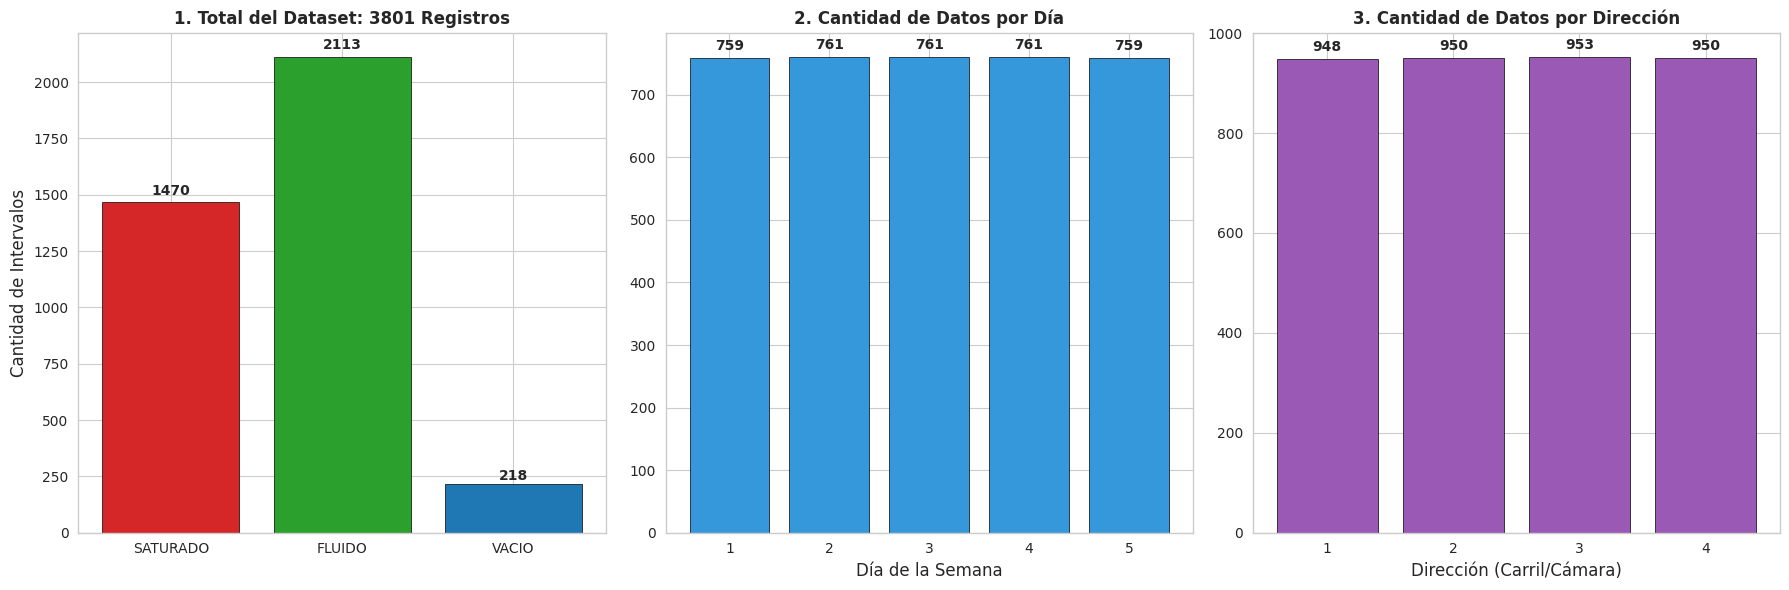

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

# =============================================================================
# 1. CONFIGURACIÓN COMPLETA (COLORES, ETIQUETAS Y DÍAS)
# =============================================================================
sns.set_style("whitegrid")

# Mapeo de Clusters (Tus reglas)
CLUSTER_LABELS = {0: 'SATURADO', 1: 'FLUIDO', 2: 'VACIO'}

# Mapeo de Días (NUEVO)
MAPA_DIAS = {
    1: 'LUNES-03-11',
    2: 'MARTES-11-11',
    3: 'MIÉRCOLES-12-11',
    4: 'JUEVES-06-11',
    5: 'VIERNES-14-11',
}

# Paleta de Colores
COLOR_MAP = {
    'SATURADO': '#d62728',  # Rojo
    'FLUIDO':   '#2ca02c',  # Verde
    'VACIO':    '#1f77b4'   # Azul
}

ORDER_CLUSTERS = ['SATURADO', 'FLUIDO', 'VACIO']

# Aplicamos el mapeo de clusters al DataFrame
# (Sobrescribimos por si acaso para asegurar consistencia)
df['Estado'] = df['cluster'].map(CLUSTER_LABELS)

# =============================================================================
# 2. GENERACIÓN DEL GRÁFICO (DÍA X DIRECCIÓN)
# =============================================================================
# Ordenamos por el número de día para que salgan en orden cronológico (L, M, X...)
dias_unicos = sorted(df['Dia_Semana'].unique())
n_dias = len(dias_unicos)

# Configuración de la grilla (2 columnas)
cols = 2
rows = math.ceil(n_dias / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows), sharey=False)

# Ajuste si solo hay 1 día para evitar errores de índice
if n_dias == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, dia_num in enumerate(dias_unicos):
    ax = axes[idx]
    
    # Obtenemos el nombre del día usando el mapa
    nombre_dia = MAPA_DIAS.get(dia_num, f'Día {dia_num}')
    
    # Filtramos datos del día numérico actual
    data_dia = df[df['Dia_Semana'] == dia_num]
    
    # Graficamos
    sns.countplot(
        data=data_dia,
        x='Direccion',
        hue='Estado',
        palette=COLOR_MAP,
        hue_order=ORDER_CLUSTERS,
        edgecolor='black',
        ax=ax
    )
    
    # --- TÍTULO CON EL NOMBRE DEL DÍA ---
    ax.set_title(f'{nombre_dia}: Estado del Tráfico por Dirección', fontsize=14, fontweight='bold', pad=15)
    
    ax.set_xlabel('Dirección', fontsize=11)
    ax.set_ylabel('Cantidad de Intervalos', fontsize=11)
    ax.legend(title='Estado', loc='upper right')
    
    # Etiquetas de valor encima de las barras
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, padding=3, fontweight='bold')

# Ocultar gráficos vacíos si sobran espacios
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()